# Feature Importance Analysis

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from pathlib import Path

In [10]:
rf_model = joblib.load("../models/random_forest.pkl")

print("Random Forest model loaded successfully.")

Random Forest model loaded successfully.


In [11]:
X_test = pd.read_csv("../data/processed/X_test.csv")

print("X_test shape:", X_test.shape)

X_test shape: (504160, 78)


In [12]:
feature_importance = rf_model.feature_importances_

print(feature_importance)

[6.17777579e-02 2.57904349e-02 1.41348438e-02 1.59917422e-02
 1.84353106e-02 2.33738505e-02 3.19634872e-02 3.45616907e-03
 2.03451006e-02 1.10722942e-02 2.51296255e-02 1.63246847e-02
 2.30951941e-02 1.34869366e-02 8.93697102e-03 5.95335262e-03
 2.85924428e-02 2.16947585e-02 2.08433915e-02 1.26630866e-02
 1.84366353e-02 2.34407337e-02 1.90485230e-02 2.11533843e-02
 1.34246708e-02 8.58148174e-03 6.51750328e-03 6.01039631e-03
 6.51385603e-03 7.27255107e-03 1.77291445e-03 0.00000000e+00
 9.62712719e-08 0.00000000e+00 1.70841478e-02 2.60823076e-02
 5.05167018e-03 1.51063970e-02 4.95039546e-03 2.68393907e-02
 2.20962428e-02 1.45008909e-02 1.67720742e-02 2.57415399e-04
 2.71288425e-03 2.21229007e-08 7.66748937e-03 5.28797912e-03
 3.42591060e-03 1.21916541e-07 0.00000000e+00 1.37599117e-03
 1.79344739e-02 1.87877707e-02 2.67915375e-02 2.13720021e-02
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 1.60218074e-02 1.86682009e-02
 9.41020271e-03 2.202950

In [13]:
importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": feature_importance
})

importance_df.head()

,Feature,Importance
0,Destination Port,0.061778
1,Flow Duration,0.025790
2,Total Fwd Packets,0.014135
3,Total Backward Packets,0.015992
4,Total Length of Fwd Packets,0.018435


In [14]:
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(10)

,Feature,Importance
0,Destination Port,0.061778
67,Init_Win_bytes_backward,0.050343
6,Fwd Packet Length Max,0.031963
16,Flow IAT Mean,0.028592
39,Max Packet Length,0.026839
54,Avg Bwd Segment Size,0.026792
35,Bwd Header Length,0.026082
1,Flow Duration,0.025790
69,min_seg_size_forward,0.025684
10,Bwd Packet Length Max,0.025130


In [15]:
importance_df.to_csv(
    "../results/feature_importance.csv",
    index=False
)

print("Feature importance table saved successfully.")

Feature importance table saved successfully.


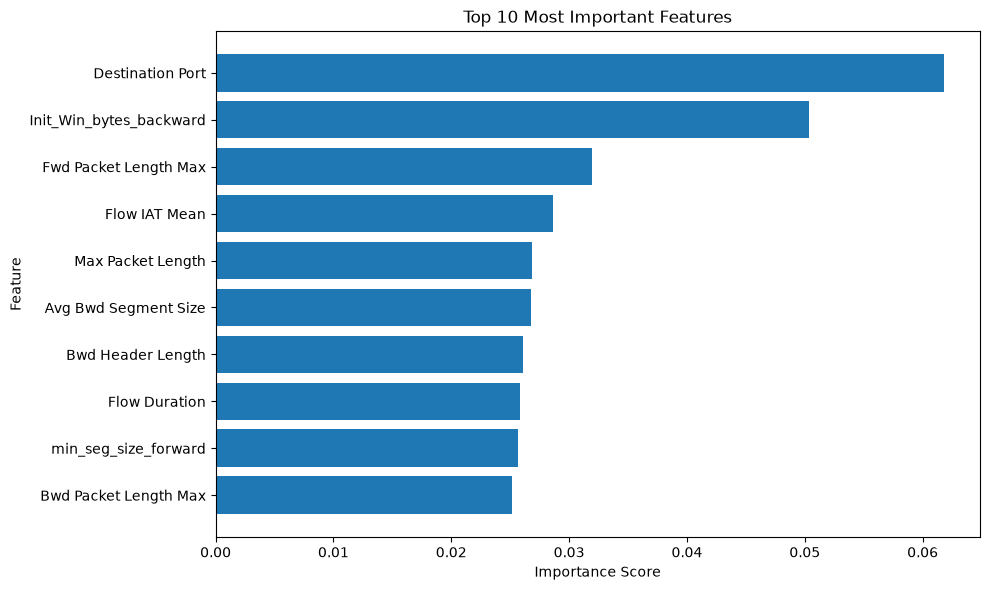

In [16]:
top_features = importance_df.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Top 10 Most Important Features")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

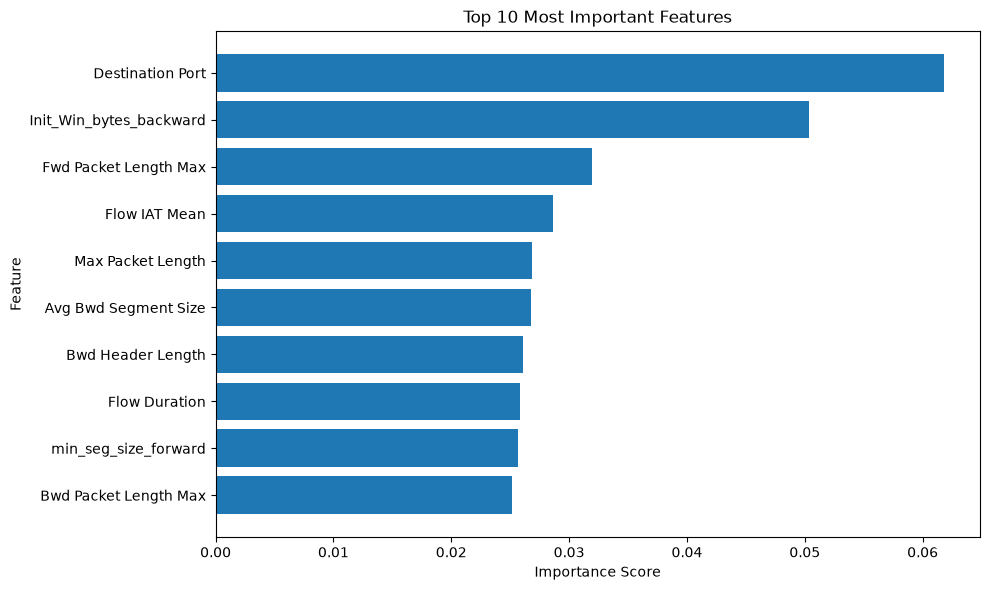

Feature importance chart saved successfully.


In [17]:
plt.figure(figsize=(10,6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Top 10 Most Important Features")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    "../results/top_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Feature importance chart saved successfully.")

In [18]:
print("Top 10 Most Important Features:")

top_features.reset_index(drop=True)

Top 10 Most Important Features:


,Feature,Importance
0,Destination Port,0.061778
1,Init_Win_bytes_backward,0.050343
2,Fwd Packet Length Max,0.031963
3,Flow IAT Mean,0.028592
4,Max Packet Length,0.026839
5,Avg Bwd Segment Size,0.026792
6,Bwd Header Length,0.026082
7,Flow Duration,0.025790
8,min_seg_size_forward,0.025684
9,Bwd Packet Length Max,0.025130
